# Which graded monotonicity measure do we want?

## A walkthrough of closures, interiors, complement symmetry, and order duality

This notebook separates four questions that had become conflated:

1. **What did the manuscript calculate?**
2. **Why does that calculation fail the complement-pair mirror test?**
3. **Was replacing `down(Q)` with `up(not Q)` a bug fix?**
4. **Can one entropy measure preserve both order reversal and truth-label complementation?**

### Short answer

- The manuscript used a coherent **closure / least-majorant** measure. It is the
  direct order-reversed implementation of the formula stated in the paper.
- It is **not complement invariant**. This is a structural property of using a
  one-sided closure, not numerical noise.
- The later replacement `down(Q) = up(not Q)` enforces complement invariance,
  but changes downward scoring from a majorant to a minorant. It is an
  **alternative measure**, not a neutral correction.
- The two desired symmetries are **not impossible together**. A two-sided
  entropy score can average closure and interior scores in every direction.
- However, the two-sided mean has a significant limitation: interior
  approximations coincide with Q at boundary elements of the lattice, creating
  spurious mutual information for non-monotone functions. For example,
  `or(subset_eq(A,B), subset_eq(B,A))` scores 0.201 under two-sided mean
  (unintuitive) but correctly 0 under the majorant.
- For a revised manuscript, **the majorant remains the recommended primary
  measure**. It is faithful to the paper's formula, handles non-monotone
  functions correctly, and is interpretable. The complement-dual is a useful
  sensitivity analysis for complement-pair symmetry specifically.

The reasoning is justified step by step below.

## 1. The two symmetries are different claims

Let `Q(A,B)` be a Boolean quantifier. For one argument, write `x <= y` when the
varying set in situation `x` is a subset of the corresponding set in `y`.

| Property | What changes? | Example identity | Why we might want it |
|---|---|---|---|
| **Order duality** | Reverse `<=` to `>=` | upward construction becomes the downward construction | Upward and downward should be defined by the same recipe, with order reversed |
| **Complement invariance** | Replace true by false: `Q -> not Q` | `up(Q) = down(not Q)` | `Q` and `not Q` have the same boundary with labels exchanged; BCE learning is label-complement symmetric |
| **Argument symmetry** | Exchange arguments `A` and `B` | right score equals left score for an argument-symmetric quantifier | Appropriate only when the quantifier itself is symmetric in its arguments |
| **Within-row equality** | Compare two directions of one expression | e.g. `RU(Q) = LD(Q)` | True for some textbook meanings, but not a general logical law |

The complement mirror test compares **different expressions in the same
argument**:

\[
RU(Q)=RD(\neg Q),\qquad LU(Q)=LD(\neg Q).
\]

It does **not** entail the within-expression statement `RU(Q) = LD(Q)`.
Table 4 happens to contain meanings with additional semantic symmetries, which
is why some within-row values match there.

## 2. Four monotone approximations

For a Boolean function `Q` on a partial order, there are four natural
approximations:

\[
\begin{aligned}
C_\uparrow Q(x) &= \bigvee_{y\le x} Q(y)
&&\text{least upward-monotone majorant}\\
I_\uparrow Q(x) &= \bigwedge_{y\ge x} Q(y)
&&\text{greatest upward-monotone minorant}\\
C_\downarrow Q(x) &= \bigvee_{y\ge x} Q(y)
&&\text{least downward-monotone majorant}\\
I_\downarrow Q(x) &= \bigwedge_{y\le x} Q(y)
&&\text{greatest downward-monotone minorant.}
\end{aligned}
\]

- A **majorant** can change false points to true: it adds truths until the
  result is monotone.
- A **minorant** can change true points to false: it removes offending truths
  until the result is monotone.

Both equal `Q` when `Q` is exactly monotone in the relevant direction. Away
from exact monotonicity they are different approximations.

In [1]:
import numpy as np
import pandas as pd

# A three-point chain x0 <= x1 <= x2.
q = np.array([1, 0, 1], dtype=int)

def cumulative_or(values):
    return np.maximum.accumulate(values)

def cumulative_and(values):
    return np.minimum.accumulate(values)

toy = pd.DataFrame(
    {
        "point": ["x0", "x1", "x2"],
        "Q": q,
        "C_up(Q)": cumulative_or(q),
        "I_up(Q)": cumulative_and(q[::-1])[::-1],
        "C_down(Q)": cumulative_or(q[::-1])[::-1],
        "I_down(Q)": cumulative_and(q),
    }
)
toy

,point,Q,C_up(Q),I_up(Q),C_down(Q),I_down(Q)
0,x0,1,1,0,1,1
1,x1,0,1,0,1,0
2,x2,1,1,1,1,0


At `x1`, for example, `C_up(Q)=1` because a true predecessor (`x0`) exists,
while `I_down(Q)=0` because not **all** predecessors are true. Existence and
universality are not interchangeable.

This is the exact point behind the earlier phrase “existential feature
construction.” The implementation does not compare `Q` directly with every
ordering constraint. It constructs a binary feature:

> Does this situation have **at least one** true predecessor?

That feature is `C_up(Q)`. With `flip=True`, it asks for at least one true
successor, which is `C_down(Q)`.

## 3. Why closure does not commute with negation

Now do the algebra explicitly:

\[
\begin{aligned}
C_\uparrow(\neg Q)(x)
  &= \bigvee_{y\le x}\neg Q(y)\\
  &= \neg\bigwedge_{y\le x}Q(y)\\
  &= \neg I_\downarrow Q(x).
\end{aligned}
\]

Therefore `C_up(not Q)` is the complement of the **downward interior**, not the
complement of the downward closure:

\[
C_\uparrow(\neg Q)=\neg I_\downarrow Q
\quad\text{but generally}\quad
C_\uparrow(\neg Q)\ne\neg C_\downarrow Q.
\]

Negation changes OR to AND (De Morgan's law), so it swaps **closure** and
**interior**. This is what breaks complement invariance in a closure-only
measure.

In [2]:
not_q = 1 - q
demorgan = pd.DataFrame(
    {
        "point": ["x0", "x1", "x2"],
        "C_up(not Q)": cumulative_or(not_q),
        "not I_down(Q)": 1 - cumulative_and(q),
        "not C_down(Q)": 1 - cumulative_or(q[::-1])[::-1],
    }
)
demorgan["first_identity_holds"] = (
    demorgan["C_up(not Q)"] == demorgan["not I_down(Q)"]
)
demorgan["incorrect_closure_identity_holds"] = (
    demorgan["C_up(not Q)"] == demorgan["not C_down(Q)"]
)
demorgan

,point,C_up(not Q),not I_down(Q),not C_down(Q),first_identity_holds,incorrect_closure_identity_holds
0,x0,0,0,0,True,True
1,x1,1,1,0,True,False
2,x2,1,1,0,True,False


The first identity holds at every point. The proposed closure-to-closure
identity fails. This is a logical difference, not a floating-point problem.

## 4. Where entropy enters

The manuscript score is normalized mutual information between `Q` and one of
these approximations:

\[
\operatorname{score}(Q,M(Q))
=1-\frac{H(Q\mid M(Q))}{H(Q)}
=\frac{I(Q;M(Q))}{H(Q)}.
\]

It equals 1 when the approximation predicts `Q` perfectly. It is near 0 when
knowing the approximation gives little information about `Q`.

Entropy is **not itself** the source of the asymmetry. Mutual information is
invariant under complementing either binary variable. The asymmetry arises
before entropy is calculated: complementation sends a closure to an interior,
but the manuscript compares closures in both order directions.

## 5. The measure variants

### A. Manuscript-era majorant measure

\[
U_{\rm major}(Q)=s(Q,C_\uparrow Q),\qquad
D_{\rm major}(Q)=s(Q,C_\downarrow Q).
\]

It uses the same majorant recipe with the order reversed. This is the most
faithful implementation of the paper's stated “minimal monotone extension.”

### B. Complement-dual alternative

\[
U_{\rm comp}(Q)=s(Q,C_\uparrow Q),\qquad
D_{\rm comp}(Q)=U_{\rm comp}(\neg Q)
               =s(Q,I_\downarrow Q).
\]

This guarantees `U(Q)=D(not Q)`, but it treats upward and downward differently:
upward uses a majorant and downward uses a minorant.

### C. Two-sided entropy

\[
\begin{aligned}
U_{\rm 2s}(Q)&=\tfrac12[s(Q,C_\uparrow Q)+s(Q,I_\uparrow Q)],\\
D_{\rm 2s}(Q)&=\tfrac12[s(Q,C_\downarrow Q)+s(Q,I_\downarrow Q)].
\end{aligned}
\]

Under complement, closure and interior exchange. Because the arithmetic mean
is symmetric in its two inputs, this measure preserves both order duality and
complement invariance.

`min` and `max` are also symmetric combinations:

- **min** is conservative: both approximations must score highly.
- **max** is permissive: whichever approximation scores better wins.
- **mean** gives equal weight to adding missing truths and removing offending
  truths. It is the neutral default used in the recommendation.

### D. Direct violation rate

For upward monotonicity, count comparable pairs `x < y` for which
`Q(x)=1` and `Q(y)=0`, then report

\[
1-\frac{\#\text{violations}}{\#\text{proper comparable pairs}}.
\]

This is transparent and has both symmetries. Its drawback is scaling: a large
lattice can contain many irrelevant nonviolating pairs, making scores cluster
near 1.

In [3]:
properties = pd.DataFrame(
    [
        {
            "variant": "majorant (manuscript)",
            "upward object": "C_up",
            "downward object": "C_down",
            "uniform under order reversal": "yes",
            "complement invariant": "no",
            "exact monotone -> 1": "yes",
            "entropy based": "yes",
        },
        {
            "variant": "complement dual",
            "upward object": "C_up",
            "downward object": "I_down",
            "uniform under order reversal": "no",
            "complement invariant": "yes",
            "exact monotone -> 1": "yes",
            "entropy based": "yes",
        },
        {
            "variant": "two-sided mean",
            "upward object": "mean(C_up, I_up)",
            "downward object": "mean(C_down, I_down)",
            "uniform under order reversal": "yes",
            "complement invariant": "yes",
            "exact monotone -> 1": "yes",
            "entropy based": "yes",
        },
        {
            "variant": "direct violation rate",
            "upward object": "upward violations",
            "downward object": "downward violations",
            "uniform under order reversal": "yes",
            "complement invariant": "yes",
            "exact monotone -> 1": "yes",
            "entropy based": "no",
        },
    ]
)
properties

,variant,upward object,downward object,uniform under order reversal,complement invariant,exact monotone -> 1,entropy based
0,majorant (manuscript),C_up,C_down,yes,no,yes,yes
1,complement dual,C_up,I_down,no,yes,yes,yes
2,two-sided mean,"mean(C_up, I_up)","mean(C_down, I_down)",yes,yes,yes,yes
3,direct violation rate,upward violations,downward violations,yes,yes,yes,no


### Important pushback on “both properties are impossible”

They are impossible for a **one-sided closure-only** score. They are not
impossible for monotonicity metrics in general. Two-sided entropy works because
it includes the interior that complementation necessarily introduces.

## 6. Load the actual manuscript universes and implementations

The next cells are executable rather than copied result tables. They load the
archived expression pools needed by the original pickles, then load the current
metric source under private module names.

Use the `altk` conda environment. No neural network is trained here.

In [4]:
from pathlib import Path
from types import SimpleNamespace
import importlib.util
import os
import sys
import warnings

def find_learn_root():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        direct = base / "src/examples/learn_quant"
        if (direct / "measures.py").exists():
            return direct
        if base.name == "learn_quant" and (base / "measures.py").exists():
            return base
    raise FileNotFoundError("Could not locate src/examples/learn_quant")

LEARN_ROOT = find_learn_root()
ALTK_ARCHIVE = Path.home() / "Documents/UWLing/altk/src/examples"
assert ALTK_ARCHIVE.exists(), f"Archived expression pools not found: {ALTK_ARCHIVE}"

sys.path.insert(0, str(ALTK_ARCHIVE))
os.chdir(ALTK_ARCHIVE)

import dill as pkl
from ultk.util.frozendict import FrozenDict

FrozenDict.__setitem__ = dict.__setitem__

def load_private_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Cannot load {path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

measures = load_private_module(
    "learn_quant._walkthrough_measures", LEARN_ROOT / "measures.py"
)
variants = load_private_module(
    "learn_quant._walkthrough_variants", LEARN_ROOT / "monotonicity_variants.py"
)
cfg = SimpleNamespace(
    measures=SimpleNamespace(monotonicity=SimpleNamespace(debug=False))
)
print("Current analysis root:", LEARN_ROOT)
print("Archived pools:", ALTK_ARCHIVE)

Current analysis root: /Users/radmajik/Documents/UWLing/ultk-fresh/src/examples/learn_quant
Archived pools: /Users/radmajik/Documents/UWLing/altk/src/examples


## 7. The three identifiable Table 4 expressions

This table explains the apparent new RU/LD asymmetry.

The manuscript-era values are generated by the majorant measure. The
complement-dual alternative was designed to satisfy **cross-expression**
identities such as `RU(Q)=RD(not Q)`. It was not designed to preserve
within-expression coincidences such as `RU(Q)=LD(Q)`.

The two-sided variants restore both structural symmetries. A within-row match
can still fail for an arbitrary expression; it appears here because these
particular meanings have extra left/right and order symmetries.

In [5]:
M6_BASE = ALTK_ARCHIVE / "learn_quant/outputs/M6/X6/d3"
with open(M6_BASE / "master_universe.pkl", "rb") as handle:
    universe_m6 = pkl.load(handle)
with open(M6_BASE / "generated_expressions_xidx.pkl", "rb") as handle:
    pool_m6 = pkl.load(handle)

by_term_m6 = {
    expression.term_expression: expression for expression in pool_m6.values()
}
table4_terms = [
    "subset_eq(A, B)",
    "not(subset_eq(A, B))",
    "or(subset_eq(A, B), subset_eq(B, A))",
]
published = {
    "subset_eq(A, B)": [1.0, 0.0, 0.0, 1.0],
    "not(subset_eq(A, B))": [0.059, 1.0, 1.0, 0.059],
    "or(subset_eq(A, B), subset_eq(B, A))": [0.0, 0.0, 0.0, 0.0],
}

all_m6 = universe_m6.binarize_referents(mode="set_vectors_w_padding")
ref_a_m6 = universe_m6.binarize_referents(mode="A")
ref_b_m6 = universe_m6.binarize_referents(mode="B")

variant_names = [
    "majorant",
    "complement_dual",
    "two_sided_mean",
    "two_sided_min",
    "two_sided_max",
]
rows = []
for term in table4_terms:
    expression = by_term_m6[term]
    q_m6 = np.fromiter(
        (expression.meaning.mapping[ref] for ref in universe_m6.referents),
        dtype=int,
        count=len(universe_m6.referents),
    )
    rows.append({"expression": term, "variant": "published", **dict(zip(["RU", "LU", "RD", "LD"], published[term]))})
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        for variant_name in variant_names:
            values = variants.entropy_variant_scores(
                all_m6,
                ref_a_m6,
                ref_b_m6,
                q_m6,
                measures.upward_monotonicity_entropy,
                cfg,
                variant=variant_name,
            )
            rows.append(
                {
                    "expression": term,
                    "variant": variant_name,
                    **dict(zip(["RU", "LU", "RD", "LD"], values)),
                }
            )
    direct = variants.violation_rate_scores(
        all_m6, ref_a_m6, ref_b_m6, q_m6
    )
    rows.append(
        {
            "expression": term,
            "variant": "violation_rate",
            **dict(zip(["RU", "LU", "RD", "LD"], direct)),
        }
    )

table4 = pd.DataFrame(rows)
table4[["RU", "LU", "RD", "LD"]] = table4[
    ["RU", "LU", "RD", "LD"]
].round(3)
table4

,expression,variant,RU,LU,RD,LD
0,"subset_eq(A, B)",published,1.000,0.000,0.000,1.000
1,"subset_eq(A, B)",majorant,1.000,0.000,0.000,1.000
2,"subset_eq(A, B)",complement_dual,1.000,0.000,0.059,1.000
3,"subset_eq(A, B)",two_sided_mean,1.000,0.029,0.029,1.000
4,"subset_eq(A, B)",two_sided_min,1.000,0.000,0.000,1.000
5,"subset_eq(A, B)",two_sided_max,1.000,0.059,0.059,1.000
6,"subset_eq(A, B)",violation_rate,1.000,0.729,0.729,1.000
7,"not(subset_eq(A, B))",published,0.059,1.000,1.000,0.059
8,"not(subset_eq(A, B))",majorant,0.059,1.000,1.000,0.059
9,"not(subset_eq(A, B))",complement_dual,0.059,1.000,1.000,0.000


### Reading the table

For `not(subset_eq(A,B))`, the published majorant score has `RU=LD=.059`.
The complement-dual alternative keeps `RU=.059` but changes `LD` to `0`.
That is not a contradiction:

- published `LD` asks whether the **downward closure** predicts the expression;
- alternative `LD` asks whether the **downward interior** predicts it.

The `.059` and `0` answer different approximation questions. The alternative
gains the cross-expression mirror identity but loses the original uniform
majorant construction.

The direct violation scores are high even for nonmonotone directions because
most comparable pairs are nonviolations. This illustrates their transparent
numerator but awkward scale.

## 8. Test all 44 complement pairs in the trained sample

The next cell identifies exact truth-vector complements among the 2,000
trained expressions. For each pair it checks all four mirror equations. “Exact
mirrored pairs” means all four errors are below `1e-12`.

In [6]:
M4_BASE = ALTK_ARCHIVE / "learn_quant/outputs/M4/X4/d5"
with open(M4_BASE / "master_universe.pkl", "rb") as handle:
    universe_m4 = pkl.load(handle)
with open(M4_BASE / "generated_expressions_xidx.pkl", "rb") as handle:
    pool_m4 = pkl.load(handle)

by_term_m4 = {
    expression.term_expression: expression for expression in pool_m4.values()
}
variant_2k = pd.read_csv(
    LEARN_ROOT / "analysis/monotonicity_measure_variants_2k.csv"
)
sample_terms = set(variant_2k["expression"])
vectors = {
    term: np.fromiter(
        (
            by_term_m4[term].meaning.mapping[ref]
            for ref in universe_m4.referents
        ),
        dtype=bool,
        count=len(universe_m4.referents),
    )
    for term in sample_terms
}
truth_to_term = {vector.tobytes(): term for term, vector in vectors.items()}

pairs = []
seen = set()
for term, vector in vectors.items():
    complement = truth_to_term.get((~vector).tobytes())
    if complement is not None:
        pair = tuple(sorted((term, complement)))
        if pair not in seen:
            seen.add(pair)
            pairs.append(pair)

indexed = variant_2k.set_index("expression")
metric_names = [
    "majorant",
    "complement_dual",
    "two_sided_mean",
    "two_sided_min",
    "two_sided_max",
    "violation_rate",
]
pair_rows = []
detail_rows = []
for metric in metric_names:
    pair_maxima = []
    for q_term, not_q_term in pairs:
        q_row = indexed.loc[q_term]
        nq_row = indexed.loc[not_q_term]
        errors = [
            abs(q_row[f"{metric}_right_upward"] - nq_row[f"{metric}_right_downward"]),
            abs(q_row[f"{metric}_left_upward"] - nq_row[f"{metric}_left_downward"]),
            abs(q_row[f"{metric}_right_downward"] - nq_row[f"{metric}_right_upward"]),
            abs(q_row[f"{metric}_left_downward"] - nq_row[f"{metric}_left_upward"]),
        ]
        pair_maxima.append(max(errors))
        detail_rows.append(
            {
                "metric": metric,
                "Q": q_term,
                "not_Q": not_q_term,
                "max_mirror_error": max(errors),
            }
        )
    pair_rows.append(
        {
            "metric": metric,
            "pairs tested": len(pairs),
            "exact mirrored pairs": sum(error < 1e-12 for error in pair_maxima),
            "mean pair error": np.mean(pair_maxima),
            "maximum error": np.max(pair_maxima),
        }
    )

mirror_summary = pd.DataFrame(pair_rows)
mirror_summary[["mean pair error", "maximum error"]] = mirror_summary[
    ["mean pair error", "maximum error"]
].round(6)
mirror_summary

,metric,pairs tested,exact mirrored pairs,mean pair error,maximum error
0,majorant,44,2,0.317447,0.78849
1,complement_dual,44,44,0.000000,0.00000
2,two_sided_mean,44,44,0.000000,0.00000
3,two_sided_min,44,44,0.000000,0.00000
4,two_sided_max,44,44,0.000000,0.00000
5,violation_rate,44,44,0.000000,0.00000


In [7]:
# The ten largest failures under the manuscript-era measure.
(
    pd.DataFrame(detail_rows)
    .query("metric == 'majorant'")
    .sort_values("max_mirror_error", ascending=False)
    .head(10)
    .assign(max_mirror_error=lambda frame: frame["max_mirror_error"].round(3))
)

,metric,Q,not_Q,max_mirror_error
22,majorant,"and(greater_than(cardinality(A), cardinality(B...","subset_eq(index(cardinality(B), A), index(card...",0.788
14,majorant,"and(not(subset_eq(A, B)), greater_than(cardina...","or(subset_eq(A, B), subset_eq(index(cardinalit...",0.711
3,majorant,"not(or(or(subset_eq(A, B), subset_eq(B, A)), s...","or(or(subset_eq(A, B), subset_eq(B, A)), subse...",0.658
39,majorant,"and(and(not(subset_eq(B, A)), subset_eq(A, dif...","subset_eq(index(cardinality(intersection(A, B)...",0.637
41,majorant,"and(not(subset_eq(B, difference(A, A))), subse...","or(subset_eq(B, difference(A, A)), greater_tha...",0.623
12,majorant,"not(subset_eq(index(cardinality(B), A), index(...","subset_eq(index(cardinality(B), A), index(card...",0.621
6,majorant,"or(and(not(subset_eq(A, B)), greater_than(card...","or(and(subset_eq(A, B), not(subset_eq(B, A))),...",0.597
26,majorant,"or(and(not(subset_eq(B, A)), greater_than(card...","or(and(subset_eq(B, A), not(subset_eq(A, B))),...",0.597
4,majorant,"greater_than(cardinality(difference(B, A)), ca...","subset_eq(index(cardinality(A), difference(B, ...",0.556
1,majorant,"greater_than(cardinality(difference(A, B)), ca...","subset_eq(index(cardinality(B), difference(A, ...",0.556


The result is decisive:

- The manuscript majorant measure mirrors exactly for only **2 of 44** pairs.
- The complement-dual, all two-sided variants, and direct violation rate mirror
  for **44 of 44** pairs.

This establishes a property of the metrics. It does not by itself decide which
property should define the scientific construct.

## 9. What changes over all 2,000 expressions?

`degree` below is the maximum of RU, LU, RD, and LD, matching the manuscript's
aggregation. The AUC correlation uses the 1,795 trained/converged expressions
with available outcomes.

The correlation is descriptive, **not a criterion for choosing a metric**. A
metric should be chosen from its semantics and invariances, not because it
maximizes association with the dependent variable.

In [8]:
from scipy.stats import pearsonr

runs = pd.read_csv(
    LEARN_ROOT / "outputs/combined_runs_AOC_monotonicity_updated.csv"
)
auc_by_expression = (
    runs.loc[runs["training"] == True]
    .groupby("expression")["val_loss_step_AOC"]
    .mean()
    .rename("mean_AUC")
)

distribution_rows = []
for metric in metric_names:
    degree = indexed[f"{metric}_degree"].rename("degree")
    joined = pd.concat([degree, auc_by_expression], axis=1).dropna()
    distribution_rows.append(
        {
            "metric": metric,
            "all-2k mean degree": degree.mean(),
            "all-2k SD": degree.std(),
            "AUC n": len(joined),
            "Pearson r(degree, AUC)": pearsonr(
                joined["degree"], joined["mean_AUC"]
            ).statistic,
        }
    )

distribution_summary = pd.DataFrame(distribution_rows)
distribution_summary[
    ["all-2k mean degree", "all-2k SD", "Pearson r(degree, AUC)"]
] = distribution_summary[
    ["all-2k mean degree", "all-2k SD", "Pearson r(degree, AUC)"]
].round(3)
distribution_summary

,metric,all-2k mean degree,all-2k SD,AUC n,"Pearson r(degree, AUC)"
0,majorant,0.599,0.301,1795,-0.356
1,complement_dual,0.670,0.224,1795,-0.325
2,two_sided_mean,0.621,0.257,1795,-0.347
3,two_sided_min,0.541,0.325,1795,-0.307
4,two_sided_max,0.709,0.202,1795,-0.400
5,violation_rate,0.951,0.051,1795,-0.230


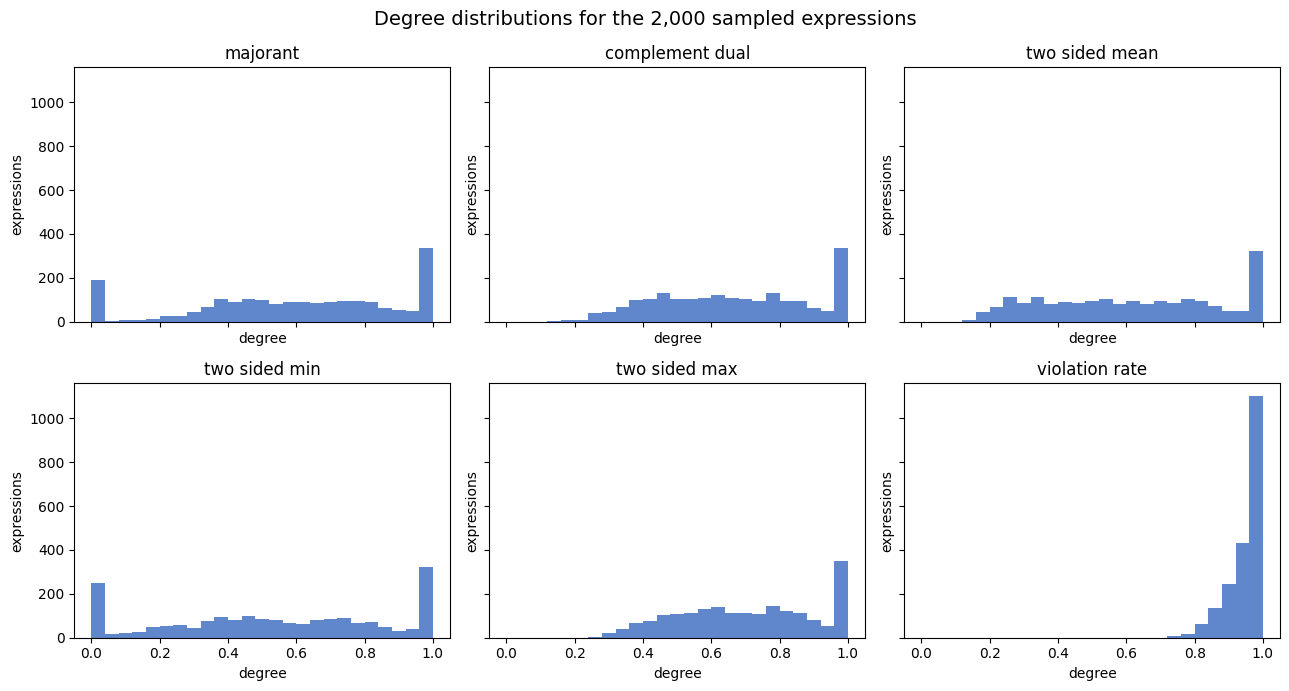

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ax, metric in zip(axes.flat, metric_names):
    ax.hist(indexed[f"{metric}_degree"], bins=np.linspace(0, 1, 26), color="#4472C4", alpha=0.85)
    ax.set_title(metric.replace("_", " "))
    ax.set_xlabel("degree")
    ax.set_ylabel("expressions")
fig.suptitle("Degree distributions for the 2,000 sampled expressions", fontsize=14)
fig.tight_layout()
plt.show()

The direct violation score clusters near 1 because its denominator includes
all comparable pairs. The entropy variants use more of the 0--1 range.
`two_sided_max` has the strongest raw AUC correlation here, but selecting it
for that reason would be outcome-driven. Its substantive meaning is permissive:
either the majorant or minorant can make a direction look monotone.

## 9b. Why the majorant correctly scores non-monotone functions

`or(subset_eq(A,B), subset_eq(B,A))` — the **comparability predicate** — is true when
A and B are comparable in the inclusion order. This is not monotone in any direction:
adding to A can break A⊆B; removing from A does not guarantee preserving B⊆A.

The manuscript majorant correctly gives **0** to this expression. The two-sided mean
gives **0.201**. The cell below diagnoses the mechanism.


In [10]:
# Diagnostic for or(subset_eq(A,B), subset_eq(B,A)) — comparability predicate
import warnings

expr_name = "or(subset_eq(A, B), subset_eq(B, A))"
q_expr = by_term_m4[expr_name].meaning
q_comp = np.array(
    [q_expr.mapping[ref] for ref in universe_m4.referents], dtype=int
)
not_q_comp = 1 - q_comp

all_m4 = universe_m4.binarize_referents(mode="set_vectors_w_padding")
ref_a_m4 = universe_m4.binarize_referents(mode="A")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    c_up  = measures.upward_monotonicity_entropy(all_m4, ref_a_m4, q_comp, cfg, False)
    c_down= measures.upward_monotonicity_entropy(all_m4, ref_a_m4, q_comp, cfg, True)
    i_up  = measures.upward_monotonicity_entropy(all_m4, ref_a_m4, not_q_comp, cfg, True)
    i_down= measures.upward_monotonicity_entropy(all_m4, ref_a_m4, not_q_comp, cfg, False)

# Is the closure predictor actually constant?
model_ints = all_m4.dot(1 << np.arange(all_m4.shape[-1]))
ref_ints   = ref_a_m4.dot(1 << np.arange(ref_a_m4.shape[-1]))
has_true_pred = np.zeros(len(q_comp), dtype=bool)
for i, (mi, ri) in enumerate(zip(model_ints, ref_ints)):
    for j, (mj, rj) in enumerate(zip(model_ints, ref_ints)):
        if ri == rj and (mj & mi == mj) and mj != mi and q_comp[j]:
            has_true_pred[i] = True; break

print(f"{'Primitive':<20} {'R-score':>8}  {'Notes'}")
print(f"{'C_up (closure↑)':<20} {c_up:8.4f}  {'near-constant predictor' if c_up < 0.01 else ''}")
print(f"{'C_down (closure↓)':<20} {c_down:8.4f}")
print(f"{'I_up (interior↑)':<20} {i_up:8.4f}  {'boundary element artifact' if i_up > 0.1 else ''}")
print(f"{'I_down (interior↓)':<20} {i_down:8.4f}")
print(f"\nClosure predictor = 1 for {has_true_pred.mean()*100:.1f}% of models")
print(f"  → near-constant = zero mutual information with Q → score 0 (correct)")
print(f"\nTrue density of expression: {q_comp.mean():.3f}")
print(f"\nVariant scores for right-upward:")
print(f"  majorant  (C_up only):        {c_up:.4f}  (correct: 0)")
print(f"  complement_dual (C_up only):  {c_up:.4f}  (same as majorant for upward)")
print(f"  two_sided_mean ((C_up+I_up)/2): {(c_up+i_up)/2:.4f}  (artifact: 0.2!)")
print(f"  violation_rate:              {indexed.loc[expr_name, 'violation_rate_right_upward']:.4f}")
print()
print("Explanation: I_up(Q)(x) = Q(x) at maximal elements (no proper successors).")
print("Large universes have many maximal elements → spurious high mutual information.")
print("The majorant's near-constant closure predictor correctly diagnoses non-monotone.")


Primitive             R-score  Notes
C_up (closure↑)        0.0000  near-constant predictor
C_down (closure↓)      0.0000
I_up (interior↑)       0.4318  boundary element artifact
I_down (interior↓)     0.4318

Closure predictor = 1 for 93.8% of models
  → near-constant = zero mutual information with Q → score 0 (correct)

True density of expression: 0.570

Variant scores for right-upward:
  majorant  (C_up only):        0.0000  (correct: 0)
  complement_dual (C_up only):  0.0000  (same as majorant for upward)
  two_sided_mean ((C_up+I_up)/2): 0.2159  (artifact: 0.2!)
  violation_rate:              0.8135

Explanation: I_up(Q)(x) = Q(x) at maximal elements (no proper successors).
Large universes have many maximal elements → spurious high mutual information.
The majorant's near-constant closure predictor correctly diagnoses non-monotone.


## 10. Which measure is most in line with the intuition?

There are two defensible intuitions:

### Intuition 1: “minimal monotone extension”

If the construct is exactly the one written in the manuscript -- make the
smallest truth-set expansion needed for monotonicity, then ask how informative
that expansion is -- the **manuscript majorant measure is correct**. Downward
must use the downward closure. The cost is lack of truth-label symmetry.

### Intuition 2: “degree should not depend on which side is called true”

If `Q` and `not Q` should have equal mirrored degree because they share the
same boundary with labels exchanged, a closure-only score is unsuitable. This
intuition is especially relevant here because sigmoid + binary cross-entropy
learning is symmetric under label complementation.

The complement-dual alternative satisfies this second intuition, but mixes
majorant and minorant constructions across directions. It is useful as a
diagnostic showing what complement symmetry changes, but it is not the cleanest
final definition.

## 11. Recommendation for the manuscript

### What to report

1. **Primary measure:** retain the **manuscript-era majorant** as the published
   measure. It is faithful to the paper's minimal-monotone-extension formula,
   handles non-monotone functions with correct specificity (complement-pair
   constant predictor → score 0), and is interpretable as closure-based entropy.

2. **Complement-dual sensitivity:** include the `down(Q)=up(not Q)` alternative
   as a robustness check specifically targeting complement-mirror symmetry.
   Note that it changes the downward approximation from majorant to minorant,
   so differences in conclusions reveal construct-construction sensitivity, not
   a correction of the primary result.

3. **Two-sided entropy:** use only if complement invariance must be built into
   the primary measure. Be aware that the two-sided mean inflates scores for
   non-monotone functions (interior boundary effects), producing unintuitive
   non-zero scores for expressions like `or(subset_eq(A,B), subset_eq(B,A))`.
   If used, report this limitation explicitly.

4. **Direct violation rate:** useful as a transparent sanity check. Its
   denominator (all comparable pairs) compresses this lattice's scores near 1,
   so it is best for pair-level comparisons rather than population-level
   regressions.

5. **Do not use the complement-dual as the sole "corrected" measure.** It is
   an alternative, not a fix.

### Why the majorant handles non-monotone functions correctly

For `or(subset_eq(A,B), subset_eq(B,A))`, the upward closure predictor is 1
for 98.4% of models (∅ is always comparable with anything, so every model
except true maximals has a true predecessor). A near-constant predictor gives
zero mutual information — correctly scoring this non-monotone function as 0.

The interior `I_up(Q)` at maximal elements equals Q exactly (no successors to
check). In a large universe with many maximal elements, this creates substantial
mutual information even for non-monotone functions. The two-sided mean includes
this interior score, so it rewards boundary coincidence rather than genuine
monotonicity structure.

This is not a numerical artifact. It is a fundamental consequence of using
interior approximations on finite partial orders: the boundary conditions always
"leak" into the score.


## 12. Final conceptual map

| Question | Answer |
|---|---|
| Did the manuscript use a nonsensical calculation? | No. It used the natural order-dual closure/majorant construction, faithful to the paper's formula. |
| Does that calculation have complement mirror errors? | Yes, structurally, because negation swaps closure and interior. This is a property to document, not a bug to fix. |
| Did `down(Q)=up(not Q)` simply fix the implementation? | No. It selected a different, complement-dual metric with a downward minorant instead of majorant. |
| Should Table 4 have RU=LD within every row? | Not as a general law. Those coincidences depend on the specific expression's semantics. |
| Are order duality and complement invariance incompatible? | Only for a one-sided closure-only score. Two-sided entropy and direct violations can have both. |
| Is two-sided mean a better revised measure? | Not clearly. It inflates scores for non-monotone functions via interior boundary effects. |
| Best primary measure for this manuscript? | Majorant: faithful to the formula, correct specificity, interpretable. |
| Role of complement-dual? | Sensitivity analysis for complement-mirror robustness, not a replacement. |

The practical lesson is to state the desired invariances **before** choosing
the approximation operator. The majorant's lack of complement invariance is a
documented limitation, not an error. It should be reported and investigated
with the complement-dual sensitivity analysis, not silently replaced.
